# Boston House Price Prediction 

## What is Data Science
- Data science is the field of extracting insights from data using statistics, programming and domain knowledge.
- It involves the entire data life cycle:Collection, cleaning, analysis,modelling and interpretation
- Goal: Make data driven decisions and generate actionable knowledge
## Data Science vs Machine Learning
- Data science: Broad field involving data processing, analysis and communication
- Machine Learning: Subset of data science focused on building predictive models
- Machine learning is used within data science projects for automation and prediction tasks

### Steps in the data science workflow
1. Problem definition
2. Data collection
3. Data cleaning
4. Exploratory Data Analysis(EDA)
5. Feature Engineering
6. Modelling
7. Evaluation
8. Deployment
9. Monitoring and updating

## Modelling in data science
- Regression: Predict continous values(e.g House Prices)
- Classification: Predict Categorical values(e.g Spam Detection)
- Clustering: Group data without labels (e.g Customer segmentations)
- Dimensionality Reduction: Reduce features while retaining meaning(e.g PCA)

## Common models and use cases
### Common algorithms for regression
- Linear Regression
- Polynomial regression
- Decision Tree regression
- Random Forest regression
- Support vector regression

## Model Evaluation metrics
- Mean square error(MSE)
- Route Mean Square error(RMSE)
- R 2 Score

## Training Process
1. Collect and process data (Handling missing values, encoding categorical variables, normalize features)
2. Split data into training and testing sets (Typically 70% to 80% training, 20% to 30% testing)
3. Choose a suitable model based on the program type classification or regression
4. Train the model by feeding it input output pairs and optimising weights
5. Evaluate model performance using metrics(accuracy,RMSE,Precision)
6. Tune hyper parameters to improve model performance
7. Deploy the model and monitor its real world performance

## Overfitting vs underfitting
- **Overfitting:** Models memorizes training data and fails on new data
- **Underfitting:** Model is too simple to capture patterns
- **Prevention:** Use cross validation, regularization, feature selection and hyper parameter tuning

# **1. Regression**
## Hands on implementation in python
## Boston Housing dataset description
- The Boston housing dataset is a classic dataset used for regression tasks. It contains 506 observations/rows and 14 variables/features/columns, including information about housing prices in various neighbourhoods in Boston

## Purpose of using this dataset
We will use linear regression to predict prices (NEDV based on these features) 
The goal is to: 
- Understand how different factors (e.g crime rates, number of rooms and tax rates)influence housing prices
- Build a linear regression model to predict house prices given neighbourhood characteristics
- Evaluate the model accuracy using mean square error and R2 score
- Visualize actual vs predicted house prices to assess model performance 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#pd.read_xls("C:/Users/hp/Desktop/AMREC/BostonHousing.xls")
boston=pd.read_csv("C:/Users/hp/Desktop/AMREC/BostonHousing.xls")

In [2]:
boston.shape

(506, 14)

In [3]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
boston.tail(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [5]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
#descriptive/summary statistics
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
#checking for sum of missing values
boston.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

# Linear Regression

In [8]:
#defining x(features) and y(targets)
#Dropping the target variable/column
x=boston.drop("medv", axis=1)
#The target variable y
y=boston["medv"]

## Splitting dataset into training and testing

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training data:{x_train.shape}")
print(f"Test data:{x_test.shape}")

Training data:(404, 13)
Test data:(102, 13)


In [10]:
#Importing linear regression library
from sklearn.linear_model import LinearRegression

In [11]:
#Initialize the model
model=LinearRegression()
#Fit/train the model
model.fit(x_train, y_train)

LinearRegression()

## Making Predictions
After trainining the models we now make predictions

In [12]:
y_pred=model.predict(x_test)
#comparing actual vs predicted
comparison=pd.DataFrame({"Actual":y_test, "predicted":y_pred})
print(comparison.head())

     Actual  predicted
173    23.6  28.996724
274    32.4  36.025565
491    13.6  14.816944
72     22.8  25.031979
452    16.1  18.769880


## Evaluating the model
To measure performance we use MSE, RMSE and R2 Score

In [13]:
from sklearn.metrics import mean_squared_error, r2_score 
mse=mean_squared_error(y_test, y_pred)
rmse=mse**0.5
r2=r2_score(y_test, y_pred)
print(f"Mean Squared Error(MSE):{mse:2f}")
print(f"Root Mean Squared Error(RMSE):{rmse:2f}")
print(f"R2 Score: {r2:2f}")

Mean Squared Error(MSE):24.291119
Root Mean Squared Error(RMSE):4.928602
R2 Score: 0.668759


### Evaluating model performance 
1. **Mean Squared Error:** 24.29
- Measures the average squared difference between the actual and predicted prices
- Lower is better since the target (medv) is in the thousands, this means the average squared error is around 24,290
  
2. **Root Mean Squared Error:** 4.93
- RMSE is the square root of MSE making it easy to interprete
- The typical prediction error is around 4,930

3. **R2 Score:** 0.67
- This indicates how much variance in the house prices is explained by our model
- R2 Score of 0.67 means 67% of the price variation is explained by the features
- A perfect model would have R2 score of 1 or 100% but real world data 0.67 or 67% is decent but not great 

## **N/B** Steps of Data science
1. Target y
2. Training and testing
3. Initialize the model
4. Fit the model
5. Make Predictions
6. Evaluate the model
7. Interpret results
8. Visualize

In [14]:
#Plotting actual vs predicted prices
import matplotlib.pyplot as plt
import seaborn as sns

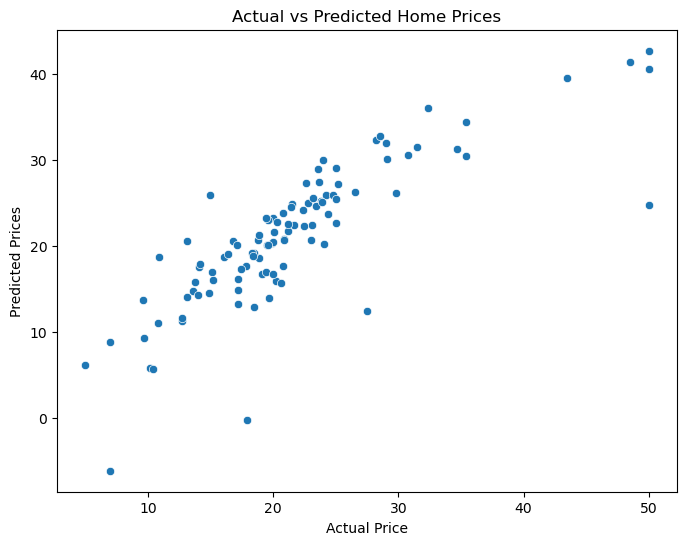

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Home Prices")
plt.show()

### Analysis of the scatterplot (actual vs predicted prices)
The plot compares the actual home prices (x-axis) with the predicted prices (y-axis) from our linear prediction model
#### Observations
- *Strong positive correlation:* The points generally follow a diagonal trend indicating our model captures the overall pattern well.
- *Some spread:* There is some diversion from the perfect diagonal line (y=x) meaning our model has some error
- *Outliers:* A few are significantly off particularly some predicted that are much lower or higher than expected

#### Residual plot to check biasness
This is the difference between the actual price and the predicted price


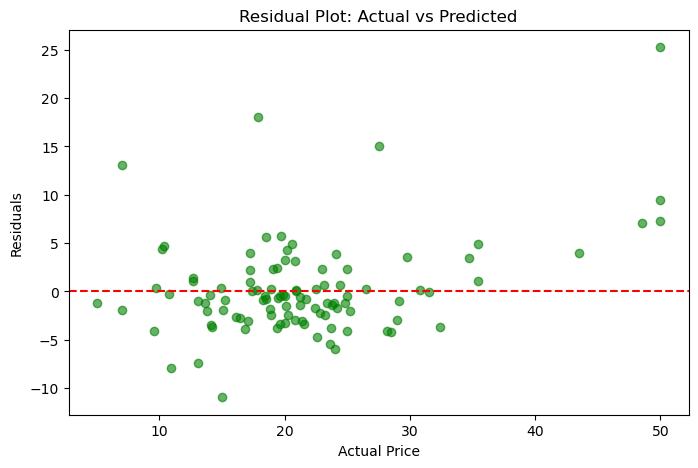

In [16]:
#Calculating residual 
residuals=y_test-y_pred
#plot the residual
plt.figure(figsize=(8,5))
plt.scatter(y_test, residuals, color="green", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Actual vs Predicted")
plt.show()

### Interpretation
*Scattered residuals around 0:*  This suggests that the linear regression model captures the general trend well

# **2. Polynomial Regression**
This is an extension of linear regression that captures non linearity by adding polynomial terms to the model. We will follow these steps:
1. Transform features by adding polynomial terms
2. Fit the model using polynomial regression
3. Evaluate the model using MSE, RMSE and R2
4. Visualize actual vs predicted prices

#### **Step1**: Transforming features by adding polynomial terms

In [17]:
#Loading Libraries for transformation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
#Creating polynomial features
poly_features=PolynomialFeatures(degree=2, include_bias=False)
#creating pipeline:polynomial transformation+linear regression
model=make_pipeline(poly_features, LinearRegression())

#### **Step2**: Fit the model using polynomial regression and then predict

In [19]:
#Training/Fitting the model
model.fit(x_train, y_train)
#Predicting the model
y_pred_poly=model.predict(x_test)

#### **Step3**: Evaluate the model using MSE,RMSE and R2 score

In [20]:
mse_poly=mean_squared_error(y_test, y_pred_poly)
rmse_poly=np.sqrt(mse_poly)
r2_poly=r2_score(y_test,y_pred_poly)
print(f"Polynomial Regression(Degree={2})Results:")
print(f"Mean Squared Error(MSE):{mse_poly:.2f}")
print(f"Root mean squared error(RMSE):{rmse_poly:.2f}")
print(f"R2 Score:{r2_poly:.2f}")

Polynomial Regression(Degree=2)Results:
Mean Squared Error(MSE):14.26
Root mean squared error(RMSE):3.78
R2 Score:0.81


##### *Comparing this to the linear regression results*
- MSE dropped from 24.29 to 14.26 (lower MSE is better)
- Rmse dropped from 4.93 to 3.78(lower RMSE is better)
- R2 increased from 0.67 to 0.81 (closer to 1 is better)
- This suggests that the polynomial(Degree=2)fits the data better than simple linear regression

#### **Step4:** Visualizing actual vs predicted

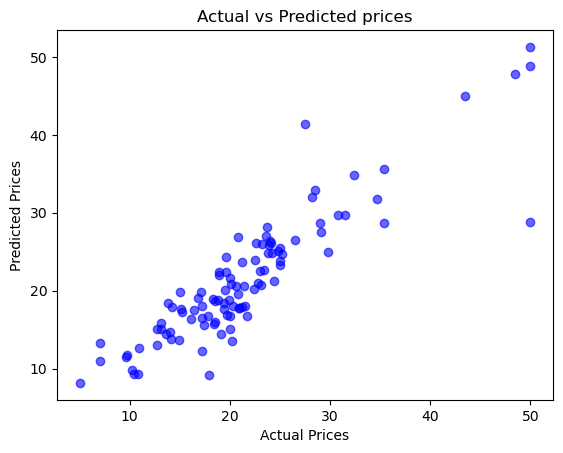

In [21]:
#Plot actual vs predicted prices
plt.scatter(y_test, y_pred_poly, color="blue", alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted prices")
plt.show()

#### **Step5:** Visualizing Residual

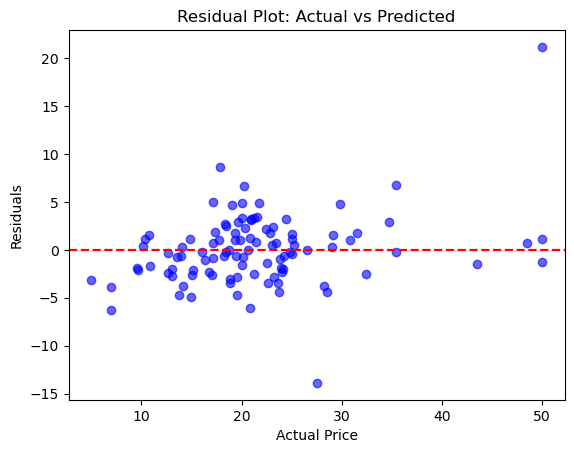

In [22]:
#Calculating residual
residuals=y_test-y_pred_poly
#plot the residual
plt.scatter(y_test, residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.6)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Actual vs Predicted")
plt.show()

#### Interpretation
- The residual looks more centered around 0 indicating that the polynomial model is capturing some non-linearity in the data

# **3.Random Forest**
Training the random forest model
- Import RandomForestClassifier (for classification) or RandomForestRegressor (for regression)
- **n/b:** continous data is regression and categorical data is classification
- Set hyper parameters (e.g number of trees, maximum depth)
- Train the model on the training set
- Use the training model to make predictions on the test set
- Evaluate the model using MSE,RMSE and R2 Score

In [23]:
#Libraries for performing random forest modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
#Model trianing
model_rf=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
#fitting the model
model_rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [25]:
#Making prediction
y_pred_rf=model_rf.predict(x_test)

In [26]:
#Evaluating the model
mse_rf=mean_squared_error(y_test, y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print(f"Random Forest Regression Results:")
print(f"Mean Squared Error(MSE):{mse_rf:.2f}")
print(f"Root mean squared error(RMSE):{rmse_rf:.2f}")
print(f"R2 Score:{r2_rf:.2f}")

Random Forest Regression Results:
Mean Squared Error(MSE):7.76
Root mean squared error(RMSE):2.79
R2 Score:0.89


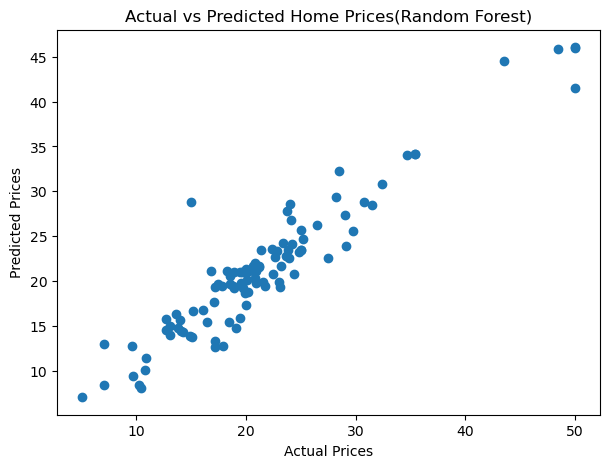

In [27]:
#Visualization of actual vs predicted prices
plt.figure(figsize=(7,5))
plt.scatter(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Home Prices(Random Forest)")
plt.show()

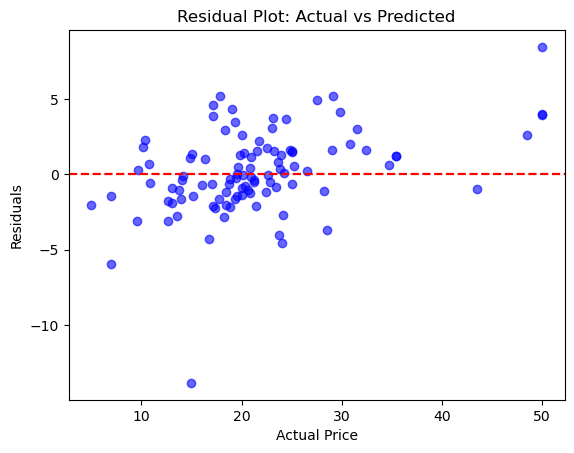

In [28]:
#Plotting residual
#Calculating residual
residuals=y_test-y_pred_rf
#plot the residual
plt.scatter(y_test, residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.6)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Actual vs Predicted")
plt.show()

# **4. Decision Tree Regression**

In [29]:
#Importing necessary libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
#Initializing the model
model_dt=DecisionTreeRegressor(random_state=42)
#Fit the model
model_dt.fit(x_train,y_train)
#Make predictions
y_pred_dt=model_dt.predict(x_test)
#Evaluate the model
mse_dt=mean_squared_error(y_test,y_pred_dt)
rmse_dt=np.sqrt(mse_dt)
r2_dt=r2_score(y_test,y_pred_dt)
print(f"Descision Tree Results:")
print(f"Mean Squared Error(MSE):{mse_dt:.2f}")
print(f"Root Mean Squared Error(RMSE):{rmse_dt:.2f}")
print(f"R2 Score(MSE):{r2_dt:.2f}")

Descision Tree Results:
Mean Squared Error(MSE):10.42
Root Mean Squared Error(RMSE):3.23
R2 Score(MSE):0.86


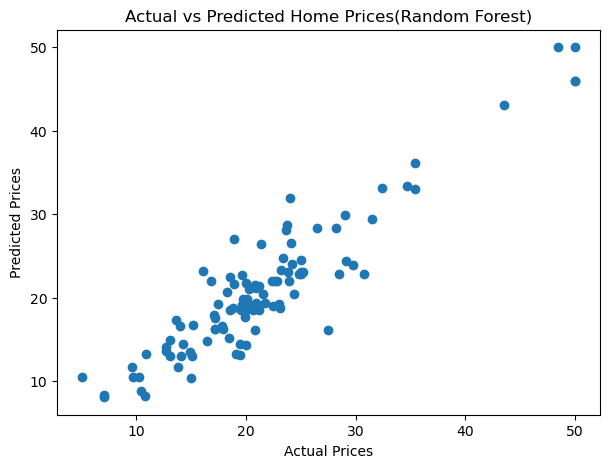

In [31]:
#Visualize actual vs predicted prices
plt.figure(figsize=(7,5))
plt.scatter(x=y_test, y=y_pred_dt)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Home Prices(Random Forest)")
plt.show()

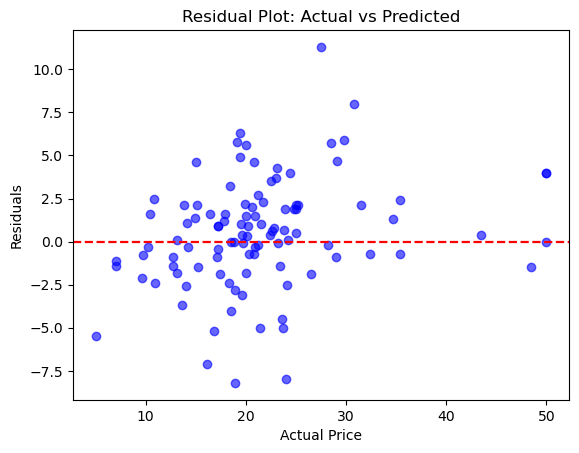

In [32]:
#Visualize Residuals
#Plotting residual
#Calculating residual
residuals=y_test-y_pred_dt
#plot the residual
plt.scatter(y_test, residuals, color="blue", alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.6)
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Actual vs Predicted")
plt.show()

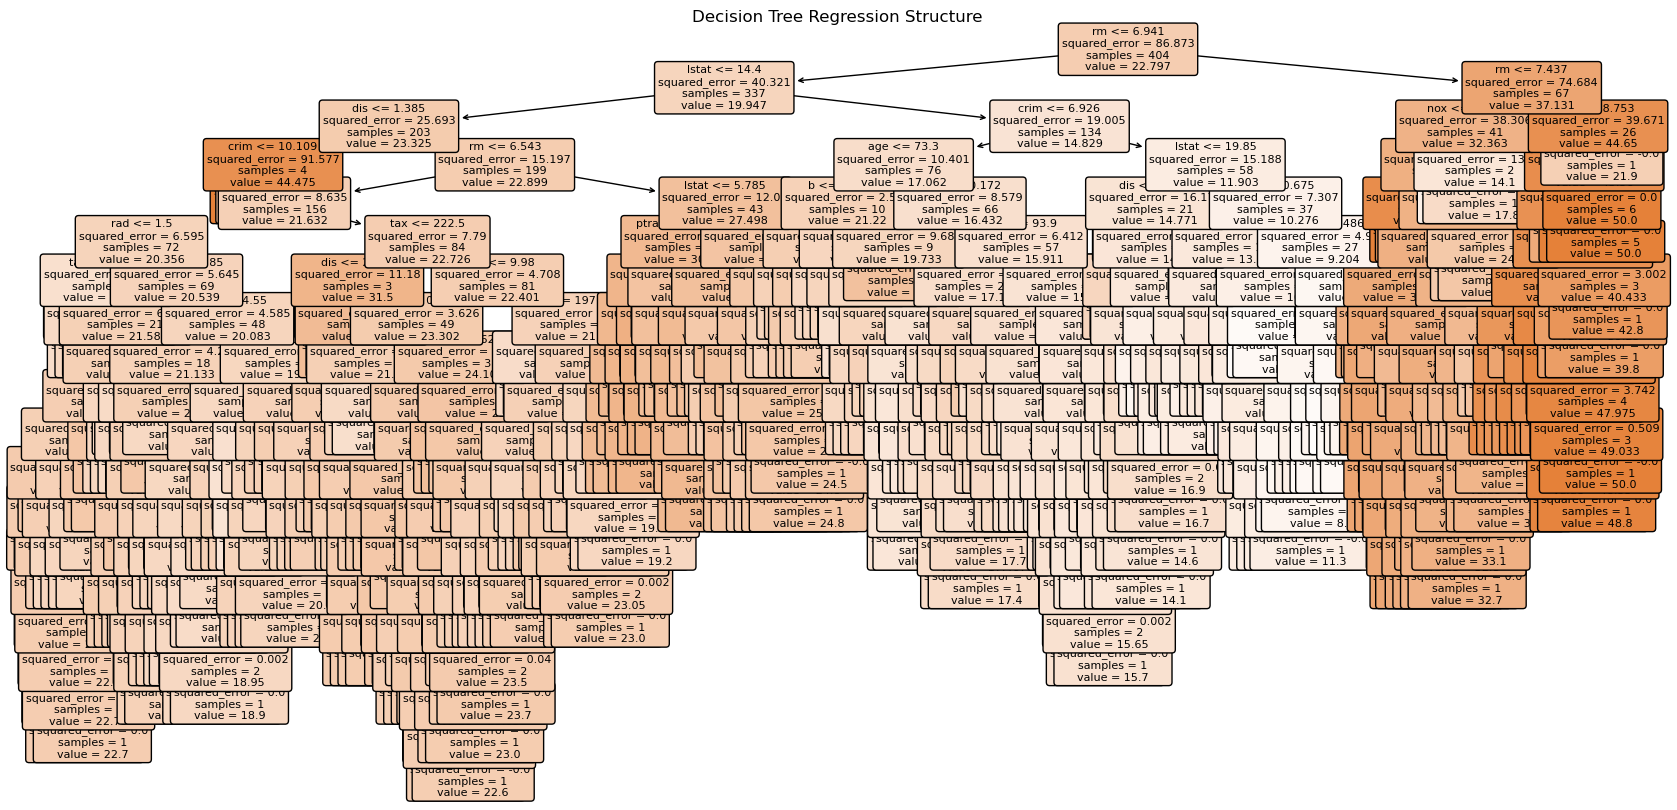

In [33]:
#Visualization Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model_dt, filled=True, feature_names=list(x_train.columns),rounded=True,fontsize=8)
plt.title("Decision Tree Regression Structure")
plt.show()

## Decision Tree Regression interpretation
- *Tree complexity:* The decision tree is deep indicating it may be overfitting to the training data
- *Feature importance:* Key predictors include LSTAT(Lower income percentage), RM(Number of rooms), CRIN(Crime rate) are all strong indicators of housing prices
- *Splitting criteria:* The model makes decisions at different feature thresholds, splitting the data to minimize the variance and error
- *Overfitting risk:* Many leaf notes contain very few samples suggesting the model may be memorizing rather generalizing
- *Next step:* Consider pruning or using random forest for improved generalization and stability

## Key Observations 
1. Random Forest has a lower MSE and RMSE
2. Random Forest has the highest R2 Score(89%)
   
#### Why is Random Forest Better
1. Reduces overfitting: Decision tree often ovefit the training data capturing noise instead of patterns. Random forest averages multiple trees making it more robust and generalizable.
2. Better performance: Combining multiplr trees allows random forest to make more accurate decisions than a single decision tree. **n/b:** If computation cost is not an issue is the better choice for regression tasks 
